# 00 – Data Exploration
**Purpose:** Understand the raw datasets before cleaning and modelling.

We will load three main datasets:
1. `crop_yield.csv` – Historical crop yields and climate/management data
2. `district_soil_lookup.csv` – Soil nutrients (N, P, K, pH) by district
3. `india_geo_features_complete.csv` – GEE‑derived rainfall, pH **and soil NPK** by lat/lon (1,137 points)

We will inspect:
- Shapes, columns, data types
- Missing values
- Distributions of numerical features
- Unique values of categorical features
- Correlations with target (`Yield`)
- Outliers and potential issues


# 1. Imports and Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import requests

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# For better display in notebook
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_rows', 100)

# 2. Load Crop Yield Data (Kaggle)

In [3]:
crop = pd.read_csv('../data/crop_yield.csv')
print("Shape:", crop.shape)
crop.head()

Shape: (19689, 10)


,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238333
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.051739
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.420909


In [4]:
crop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crop             19689 non-null  object 
 1   Crop_Year        19689 non-null  int64  
 2   Season           19689 non-null  object 
 3   State            19689 non-null  object 
 4   Area             19689 non-null  float64
 5   Production       19689 non-null  int64  
 6   Annual_Rainfall  19689 non-null  float64
 7   Fertilizer       19689 non-null  float64
 8   Pesticide        19689 non-null  float64
 9   Yield            19689 non-null  float64
dtypes: float64(5), int64(2), object(3)
memory usage: 1.5+ MB


In [5]:
crop.describe()

,Crop_Year,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
count,19689.000000,1.968900e+04,1.968900e+04,19689.000000,1.968900e+04,1.968900e+04,19689.000000
mean,2009.127584,1.799266e+05,1.643594e+07,1437.755177,2.410331e+07,4.884835e+04,79.954009
std,6.498099,7.328287e+05,2.630568e+08,816.909589,9.494600e+07,2.132874e+05,878.306193
min,1997.000000,5.000000e-01,0.000000e+00,301.300000,5.417000e+01,9.000000e-02,0.000000
25%,2004.000000,1.390000e+03,1.393000e+03,940.700000,1.880146e+05,3.567000e+02,0.600000
50%,2010.000000,9.317000e+03,1.380400e+04,1247.600000,1.234957e+06,2.421900e+03,1.030000
75%,2015.000000,7.511200e+04,1.227180e+05,1643.700000,1.000385e+07,2.004170e+04,2.388889
max,2020.000000,5.080810e+07,6.326000e+09,6552.700000,4.835407e+09,1.575051e+07,21105.000000


In [6]:
crop.isnull().sum()

Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production         0
Annual_Rainfall    0
Fertilizer         0
Pesticide          0
Yield              0
dtype: int64

In [7]:
print("Crop unique values:", crop['Crop'].nunique())
print("Season unique values:", crop['Season'].nunique())
print("State unique values:", crop['State'].nunique())

print("\nSample crops:", crop['Crop'].unique()[:10])
print("\nSeasons:", crop['Season'].unique())
print("\nStates:", crop['State'].unique()[:10])

Crop unique values: 55
Season unique values: 6
State unique values: 30

Sample crops: ['Arecanut' 'Arhar/Tur' 'Castor seed' 'Coconut ' 'Cotton(lint)'
 'Dry chillies' 'Gram' 'Jute' 'Linseed' 'Maize']

Seasons: ['Whole Year ' 'Kharif     ' 'Rabi       ' 'Autumn     ' 'Summer     '
 'Winter     ']

States: ['Assam' 'Karnataka' 'Kerala' 'Meghalaya' 'West Bengal' 'Puducherry' 'Goa'
 'Andhra Pradesh' 'Tamil Nadu' 'Odisha']


# 3. Load District Soil Lookup (N, P, K, pH)

In [8]:
soil = pd.read_csv('../data/district_soil_lookup.csv')
print("Shape:", soil.shape)
soil.head(10)

Shape: (738, 6)


,state_name,district_name,Nitrogen,Phosphorus,Potassium,Soil Ph
0,Andaman And Nicobar Islands,Nicobars,4.727811,4.727811,4.727811,4.727811
1,Andaman And Nicobar Islands,North And Middle Andaman,20.018349,20.018349,20.018349,20.018349
2,Andaman And Nicobar Islands,South Andamans,11.195876,11.195876,11.195876,11.195876
3,Andhra Pradesh,Alluri Sitharama Raju,2.685761,2.688889,2.690864,2.645267
4,Andhra Pradesh,Anakapalli,9.231490,9.246363,9.238927,9.229227
5,Andhra Pradesh,Ananthapuramu,11.105403,11.104262,11.103881,11.106164
6,Andhra Pradesh,Annamayya,11.323037,11.370227,11.432432,11.057057
7,Andhra Pradesh,Bapatla,17.438095,17.414603,17.438095,17.438095
8,Andhra Pradesh,Chittoor,8.226020,8.231055,8.231055,8.216216
9,Andhra Pradesh,Dr. B.R. Ambedkar Konaseema,16.268238,16.268238,16.272727,16.261504


In [9]:
soil.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 738 entries, 0 to 737
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   state_name     738 non-null    object 
 1   district_name  738 non-null    object 
 2   Nitrogen       738 non-null    float64
 3   Phosphorus     738 non-null    float64
 4   Potassium      738 non-null    float64
 5   Soil Ph        738 non-null    float64
dtypes: float64(4), object(2)
memory usage: 34.7+ KB


In [10]:
# Check for missing values in soil data
soil.isnull().sum()

state_name       0
district_name    0
Nitrogen         0
Phosphorus       0
Potassium        0
Soil Ph          0
dtype: int64

In [11]:
soil.describe()

,Nitrogen,Phosphorus,Potassium,Soil Ph
count,738.000000,738.000000,738.000000,738.000000
mean,21.718082,26.955325,26.975794,27.181404
std,36.199610,39.685663,39.666869,39.695031
min,0.000000,0.000000,0.000000,0.000000
25%,6.589072,7.659981,7.662013,7.726549
50%,11.688272,13.741807,13.746363,13.775469
75%,31.399201,33.330005,33.331571,33.280685
max,715.333333,715.666667,715.666667,715.333333


# 4. Load GEE Geo Features (rainfall, pH & NPK by lat/lon)


In [12]:
geo = pd.read_csv('../data/india_geo_features_complete.csv')
print("Shape:", geo.shape)
print("Columns:", geo.columns.tolist())
geo.head(10)


Shape: (1137, 7)
Columns: ['longitude', 'latitude', 'avg_rainfall_mm', 'soil_ph', 'Nitrogen', 'Phosphorous', 'Potassium']


,longitude,latitude,avg_rainfall_mm,soil_ph,Nitrogen,Phosphorous,Potassium
0,77.322488,8.152211,2698.178401,5.6,17.916667,17.920290,17.923913
1,76.828415,8.646285,4377.944946,5.7,0.057692,47.096154,47.115385
2,77.322488,8.646285,3421.822819,5.4,9.190741,9.190741,9.190741
3,77.816561,8.646285,2096.451408,7.2,15.160256,15.160256,15.160256
4,76.828415,9.140358,5433.940539,5.4,0.010256,32.348718,32.379487
5,77.322488,9.140358,3436.787036,5.4,9.190741,9.190741,9.190741
6,77.816561,9.140358,2070.078375,7.5,15.160256,15.160256,15.160256
7,78.310635,9.140358,1543.255322,7.2,17.349727,17.355972,17.358314
8,76.334341,9.634431,7153.444546,5.7,0.084291,28.842912,28.846743
9,76.828415,9.634431,5292.179458,5.1,0.041237,25.302405,25.319588


In [13]:
geo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1137 entries, 0 to 1136
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   longitude        1137 non-null   float64
 1   latitude         1137 non-null   float64
 2   avg_rainfall_mm  1137 non-null   float64
 3   soil_ph          1137 non-null   float64
 4   Nitrogen         1137 non-null   float64
 5   Phosphorous      1137 non-null   float64
 6   Potassium        1137 non-null   float64
dtypes: float64(7)
memory usage: 62.3 KB


In [14]:
# Check for missing values
geo.isnull().sum()

longitude          0
latitude           0
avg_rainfall_mm    0
soil_ph            0
Nitrogen           0
Phosphorous        0
Potassium          0
dtype: int64

In [15]:
geo.describe()

,longitude,latitude,avg_rainfall_mm,soil_ph,Nitrogen,Phosphorous,Potassium
count,1137.000000,1137.000000,1137.000000,1137.000000,1137.000000,1137.000000,1137.000000
mean,79.586013,22.830146,2435.343106,6.909059,20.616347,24.124587,24.149311
std,5.853462,5.532597,1365.361426,0.775651,55.126438,56.427794,56.421700
min,68.429167,8.152211,269.854891,5.100000,0.000000,0.000000,0.000000
25%,75.840268,19.515900,1585.544431,6.300000,6.079441,7.482377,7.483384
50%,78.310635,23.468487,2213.681879,7.000000,10.891188,11.450032,11.483245
75%,82.263222,26.432927,2991.270172,7.500000,18.831615,25.273292,25.784685
max,97.085424,35.326249,8881.059367,8.300000,715.333333,715.666667,715.666667


# 4b. GEE Geo Features – NPK Distribution Analysis


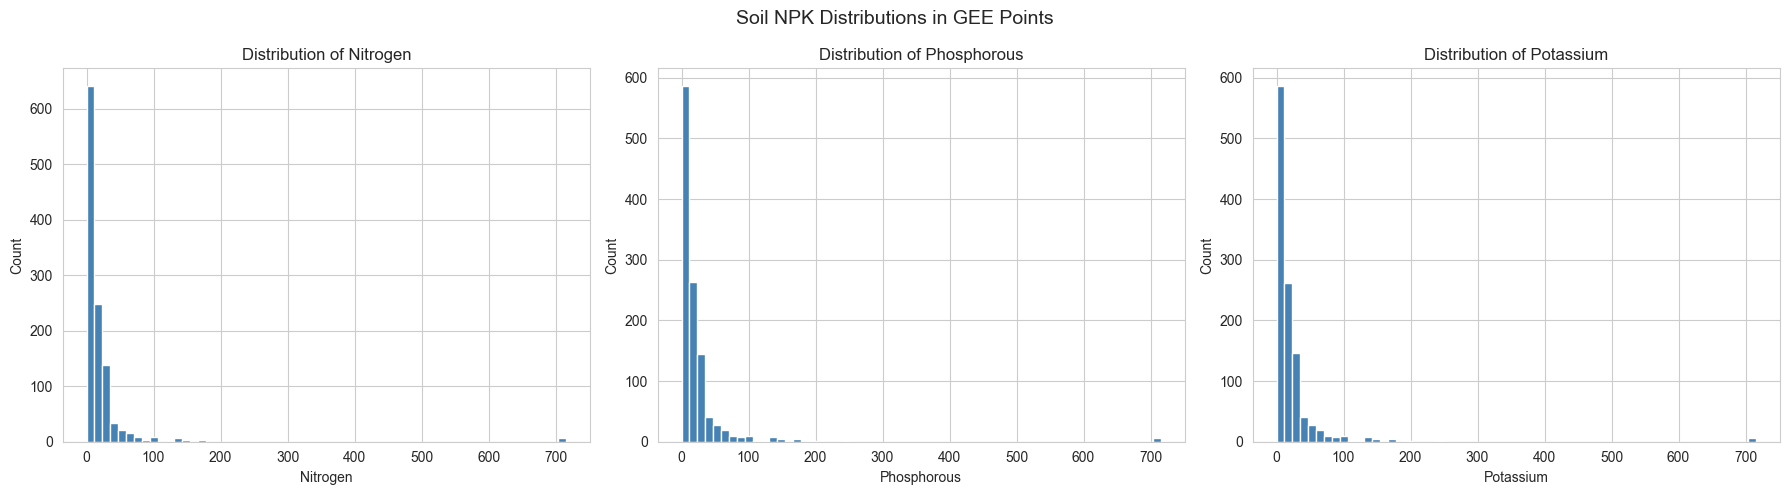

In [16]:
# Distribution of NPK columns in geo data
npk_cols = ['Nitrogen', 'Phosphorous', 'Potassium']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, npk_cols):
    geo[col].hist(bins=60, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
plt.suptitle('Soil NPK Distributions in GEE Points', fontsize=14)
plt.tight_layout()
plt.show()


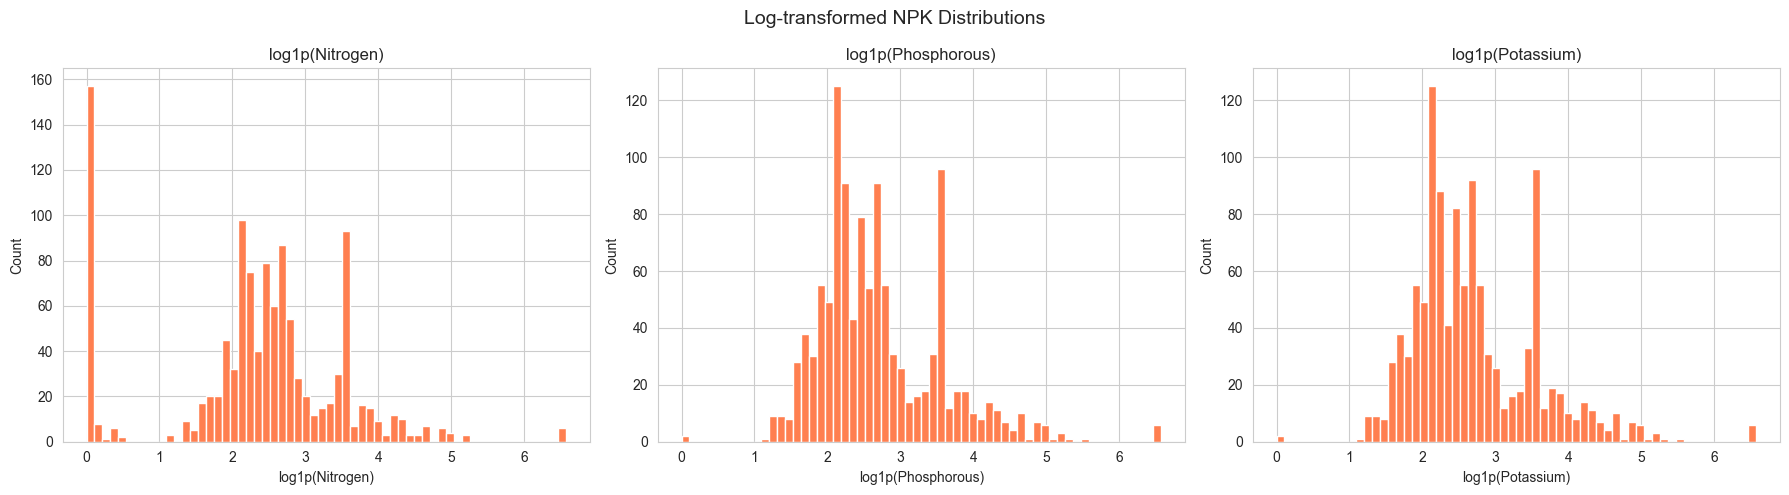

In [17]:
# Log-transform NPK (skewed) for visual clarity
import numpy as np
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, npk_cols):
    np.log1p(geo[col]).hist(bins=60, ax=ax, color='coral', edgecolor='white')
    ax.set_title(f'log1p({col})')
    ax.set_xlabel(f'log1p({col})')
    ax.set_ylabel('Count')
plt.suptitle('Log-transformed NPK Distributions', fontsize=14)
plt.tight_layout()
plt.show()


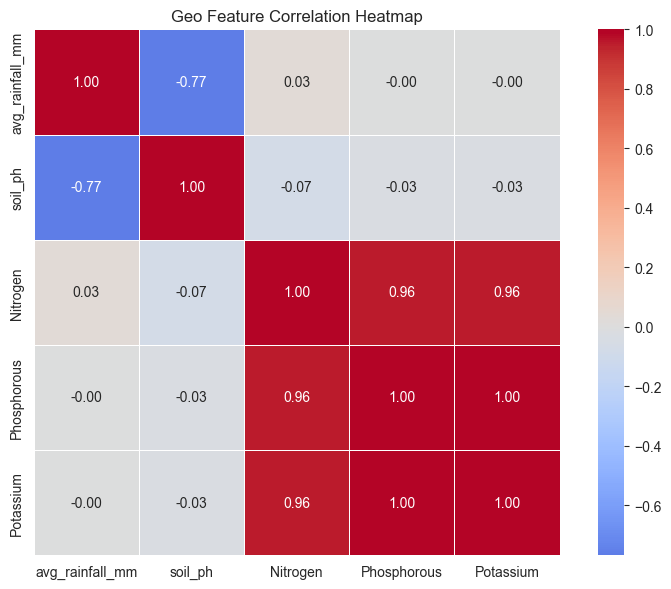

In [18]:
# Correlation heatmap – all 5 geo features
geo_num = geo[['avg_rainfall_mm', 'soil_ph', 'Nitrogen', 'Phosphorous', 'Potassium']]
corr = geo_num.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Geo Feature Correlation Heatmap')
plt.tight_layout()
plt.show()


In [19]:
# Scatter: rainfall vs soil_ph, coloured by Nitrogen
fig = px.scatter(geo, x='avg_rainfall_mm', y='soil_ph',
                 color='Nitrogen', size='Potassium',
                 hover_data=['Phosphorous', 'latitude', 'longitude'],
                 title='Rainfall vs Soil pH (colour=Nitrogen, size=Potassium)',
                 color_continuous_scale='Viridis')
fig.show()


In [20]:
# Outlier check for NPK
print("=== NPK outlier check ===")
for col in npk_cols:
    Q1, Q3 = geo[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    n_out = (geo[col] > upper).sum()
    print(f"{col}: Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}, "
          f"upper fence={upper:.2f}, outliers above fence={n_out}")


=== NPK outlier check ===
Nitrogen: Q1=6.08, Q3=18.83, IQR=12.75, upper fence=37.96, outliers above fence=103
Phosphorous: Q1=7.48, Q3=25.27, IQR=17.79, upper fence=51.96, outliers above fence=87
Potassium: Q1=7.48, Q3=25.78, IQR=18.30, upper fence=53.24, outliers above fence=86


# 5. Merge Crop and Soil Data (for training)
Note: The original crop dataset only has State, not district.
We'll average soil values per state for now.

In [21]:
# Standardise state names
crop['State_clean'] = crop['State'].str.upper().str.strip()

# Soil: average per state (if state column exists)
# The district_soil_lookup.csv has district_name and may not have state_name.
# Let's check columns
soil.columns

Index(['state_name', 'district_name', 'Nitrogen', 'Phosphorus', 'Potassium',
       'Soil Ph'],
      dtype='object')

In [22]:
# If 'state_name' missing, we cannot merge directly.
# For this exploration, we'll just note the issue.
# In the final cleaning notebook, we'll add state names from a separate mapping.
print("Note: district_soil_lookup.csv does not contain state_name column.")
print("We will need to add it using a district‑state mapping file.")

Note: district_soil_lookup.csv does not contain state_name column.
We will need to add it using a district‑state mapping file.


# 6. Visualise Target Variable (Yield)

In [23]:
fig = px.histogram(crop, x='Yield', nbins=100, title='Distribution of Crop Yield (tons/hectare)')
fig.show()

In [24]:
# Boxplot to see outliers
fig = px.box(crop, y='Yield', title='Yield Boxplot')
fig.show()

In [25]:
# Log transformation to reduce skew
crop['log_yield'] = np.log1p(crop['Yield'])
fig = px.histogram(crop, x='log_yield', nbins=100, title='Log‑transformed Yield')
fig.show()

# 7. Categorical Feature Analysis

In [26]:
# Yield by Crop (top 20 crops by count)
top_crops = crop['Crop'].value_counts().head(20).index
crop_top = crop[crop['Crop'].isin(top_crops)]
fig = px.box(crop_top, x='Crop', y='Yield', title='Yield by Crop (top 20)')
fig.update_xaxes(tickangle=45)
fig.show()

In [27]:
# Yield by Season
fig = px.box(crop, x='Season', y='Yield', title='Yield by Season')
fig.show()

In [28]:
# Yield by State (top 10 states)
top_states = crop['State'].value_counts().head(10).index
crop_states = crop[crop['State'].isin(top_states)]
fig = px.box(crop_states, x='State', y='Yield', title='Yield by State (top 10)')
fig.update_xaxes(tickangle=45)
fig.show()

# 8. Correlation Analysis (Numerical Features)

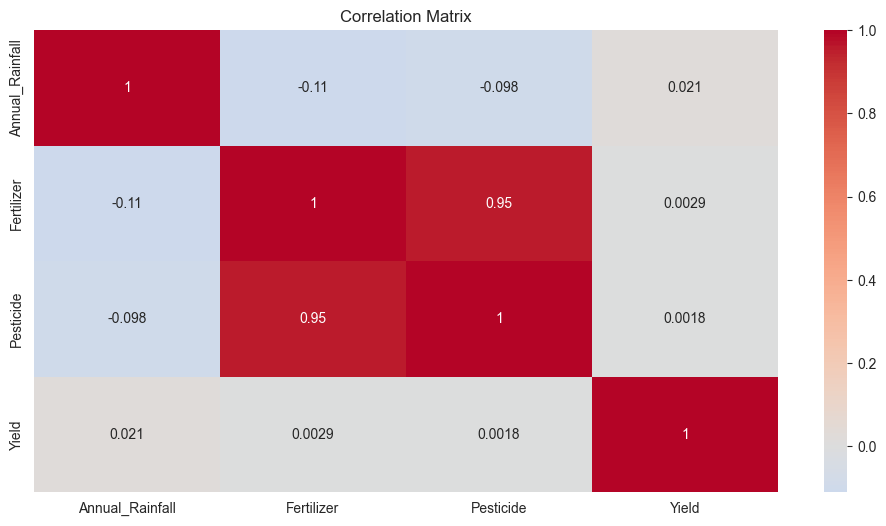

In [29]:
# Select numerical columns from crop data (excluding Crop_Year, Area, Production – they are not features or leak target)
num_cols = ['Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield']
corr_matrix = crop[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

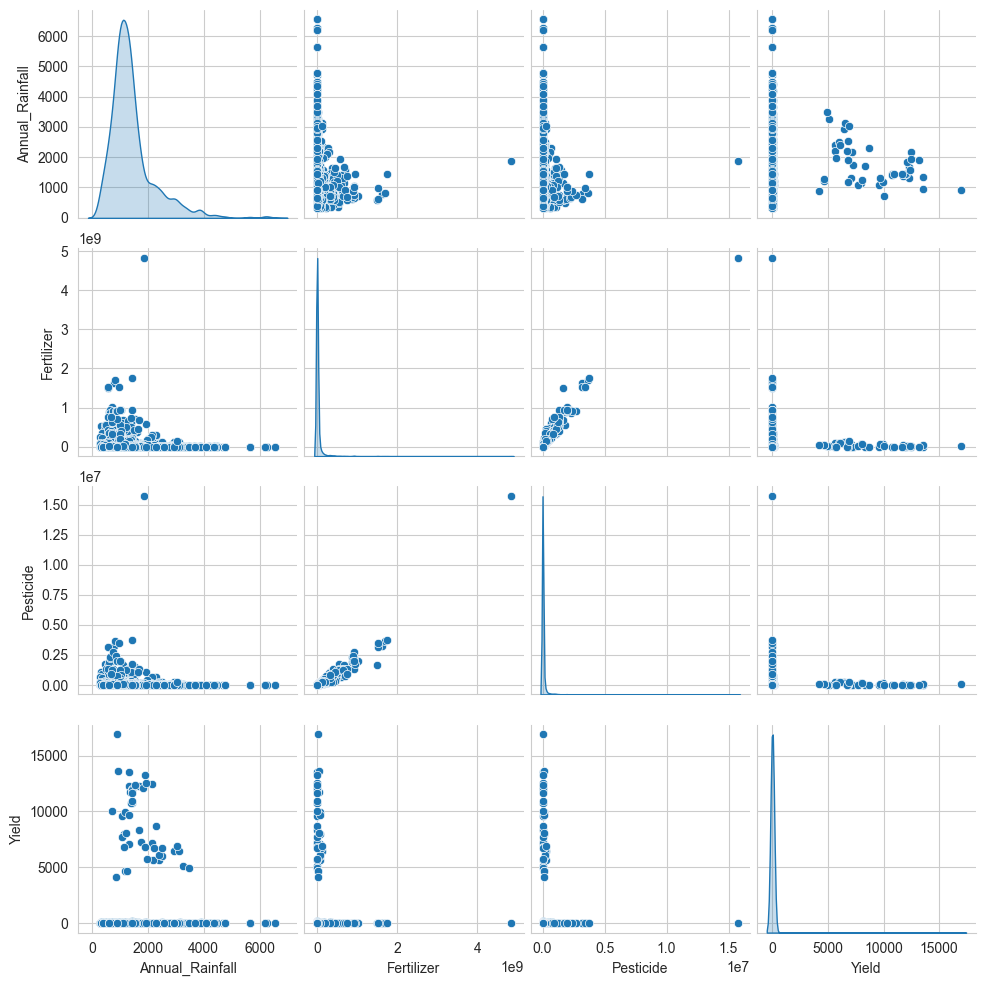

In [30]:
# Pairplot (sample to avoid overcrowding)
sample = crop[num_cols].sample(5000)
sns.pairplot(sample, diag_kind='kde')
plt.show()

# 9. Check for Outliers and Impossible Values

In [31]:
# Yield: realistic range 0–20 tons/hectare for most crops (sugarcane can be higher)
print("Yield > 100:", crop[crop['Yield'] > 100].shape[0])
print("Yield < 0:", crop[crop['Yield'] < 0].shape[0])
print("Fertilizer negative:", crop[crop['Fertilizer'] < 0].shape[0])
print("Pesticide negative:", crop[crop['Pesticide'] < 0].shape[0])
print("Rainfall negative:", crop[crop['Annual_Rainfall'] < 0].shape[0])

Yield > 100: 204
Yield < 0: 0
Fertilizer negative: 0
Pesticide negative: 0
Rainfall negative: 0


# 10. Geographic Distribution of GEE Points

In [32]:
fig = px.scatter_mapbox(
    geo,
    lat='latitude',
    lon='longitude',
    color='avg_rainfall_mm',
    size='soil_ph',
    hover_name='avg_rainfall_mm',
    hover_data={'Nitrogen': True, 'Phosphorous': True, 'Potassium': True,
                'avg_rainfall_mm': True, 'soil_ph': True},
    title='GEE Sample Points across India (rainfall, pH, NPK)',
    mapbox_style='open-street-map',
    zoom=3.5
)
fig.show()


C:\Users\Dell\AppData\Local\Temp\ipykernel_20104\3878666403.py:1: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



# 10b. Geographic Distribution of NPK Values


In [33]:
# Map Nitrogen spread across India
fig = px.scatter_mapbox(
    geo, lat='latitude', lon='longitude',
    color='Nitrogen', size='Phosphorous',
    hover_data={'Potassium': True, 'Nitrogen': True, 'Phosphorous': True,
                'avg_rainfall_mm': True, 'soil_ph': True},
    title='Nitrogen Distribution across India (size = Phosphorous)',
    mapbox_style='open-street-map', zoom=3.5,
    color_continuous_scale='YlOrRd'
)
fig.show()


C:\Users\Dell\AppData\Local\Temp\ipykernel_20104\928128853.py:2: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



# 11. Summary and Key Takeaways

**Findings:**
- Crop yield dataset has 19,689 rows, no missing values, but `Area`, `Production`, `Crop_Year` are not useful as features (they leak target or are irrelevant).
- Target `Yield` is highly skewed – log transformation may help.
- Categorical columns (`Crop`, `Season`, `State`) have good variety; many crops and states.
- Soil lookup has district‑level N, P, K, pH but **lacks state information** – we need a district‑state mapping.
- GEE points (`india_geo_features_complete.csv`) now contain **7 features**: `longitude`, `latitude`, `avg_rainfall_mm`, `soil_ph`, `Nitrogen`, `Phosphorous`, `Potassium` across **1,137 points** with zero missing values. This removes the need to rely solely on `district_soil_lookup.csv` for NPK – the GEE CSV can serve as the primary geo‑feature source.
- Rainfall range: 270–8,881 mm; pH: 5.1–8.3; NPK values show expected skew (some very high outlier districts).

**Next steps:**
1. Use `india_geo_features_complete.csv` as the primary geo‑feature source for lat/lon lookups (rainfall + pH + NPK).
2. Optionally retain `district_soil_lookup.csv` as a fallback for state‑level aggregation.
3. Proceed to **01_data_cleaning.ipynb**.
